# Embed your sequences with esm2

Example you go to uniprot and want to apply func-e on some dataset so you search for "halogenases". Then you want to test them on func-e. To do this you need to embed this "search space" using esm2 first. This notebook does that.

## Example searching uniprot:

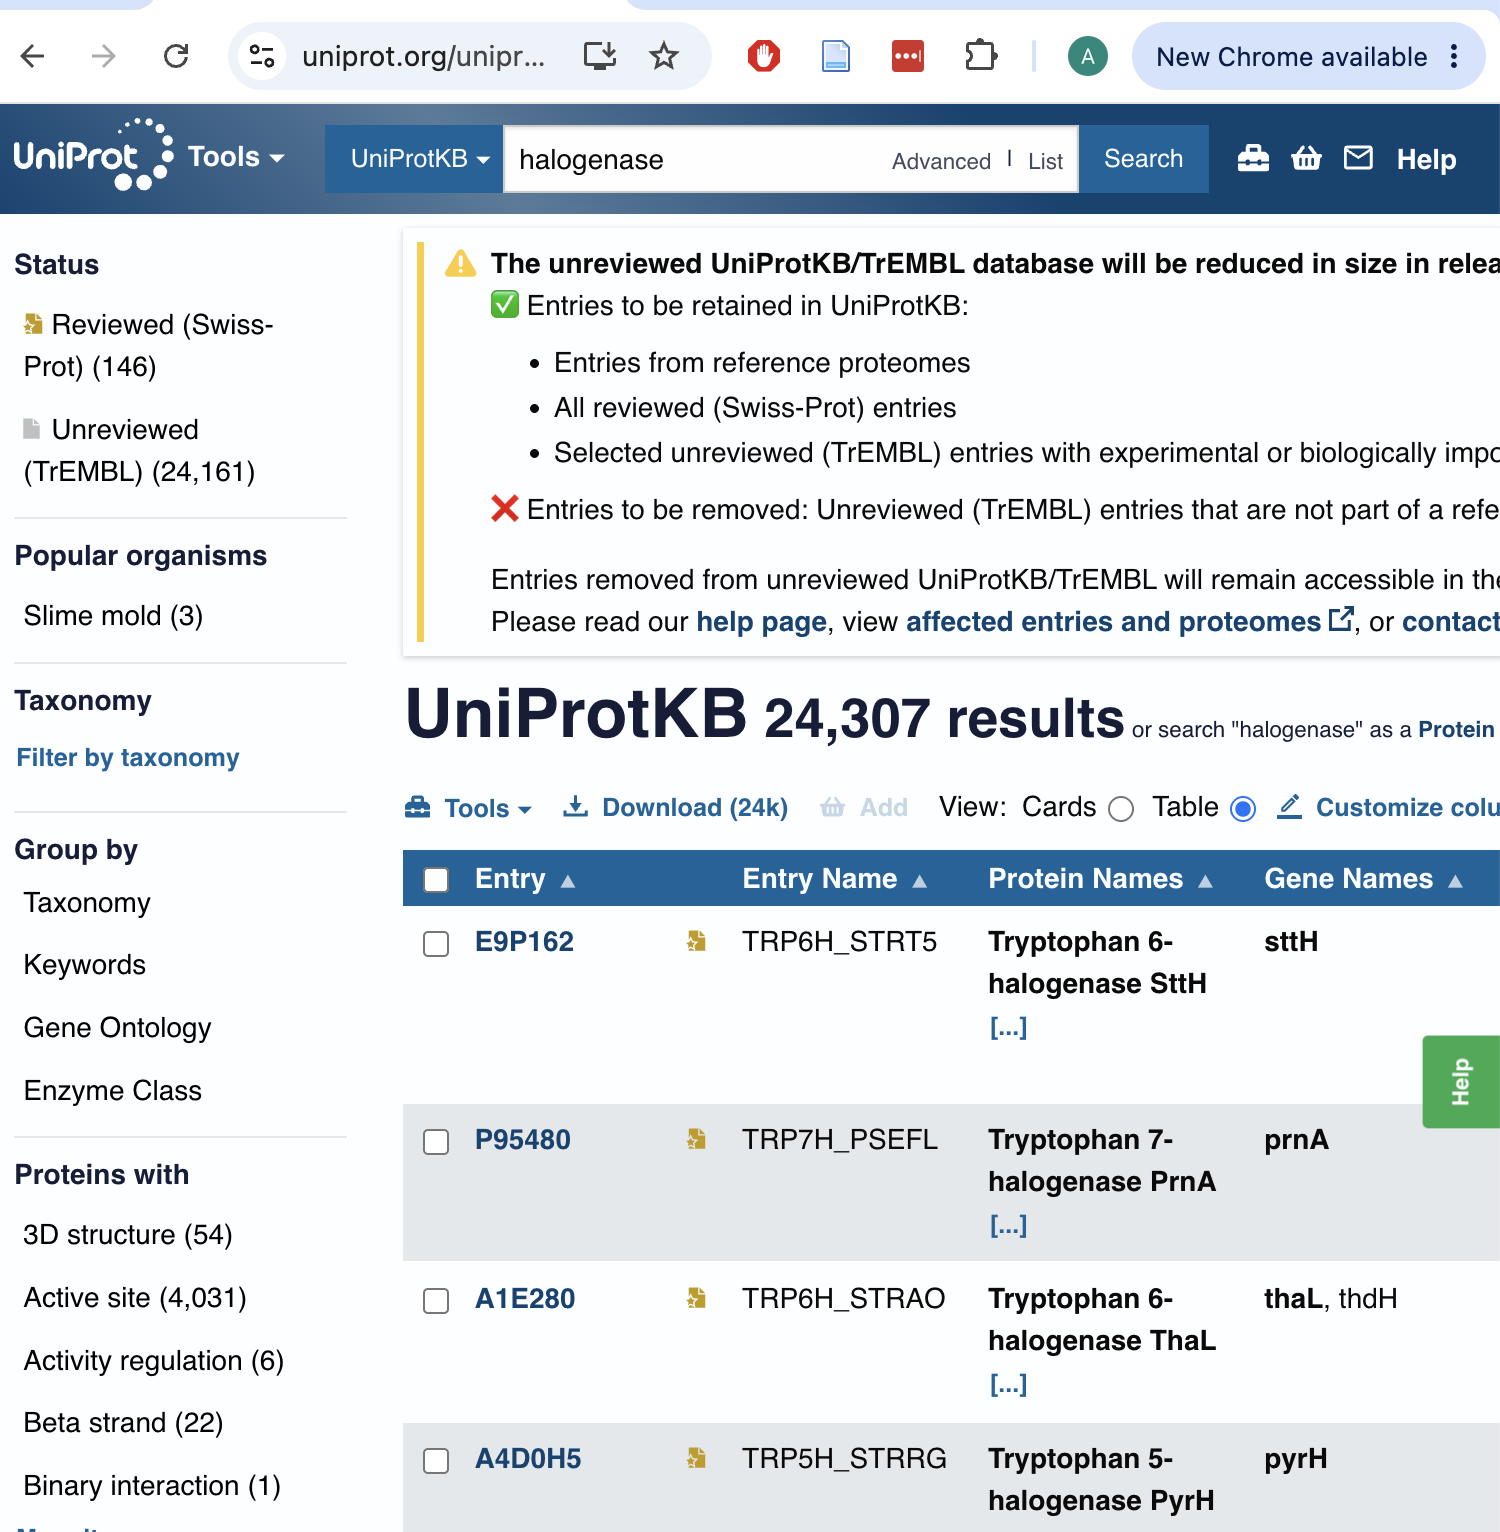

## Select tsv download and select the following columns

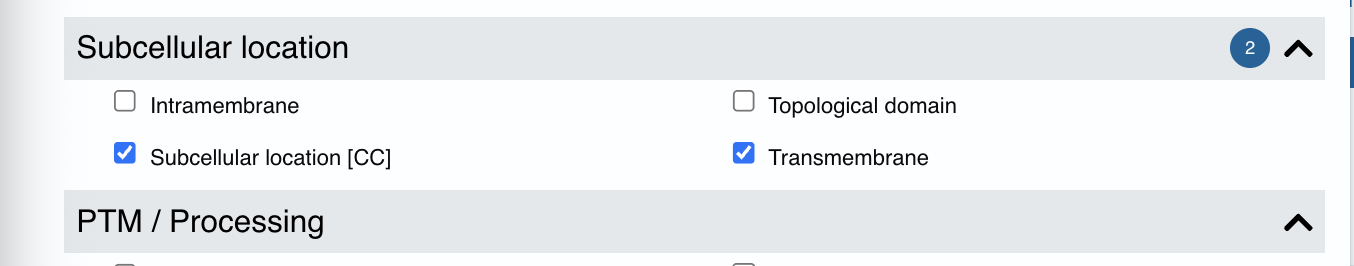

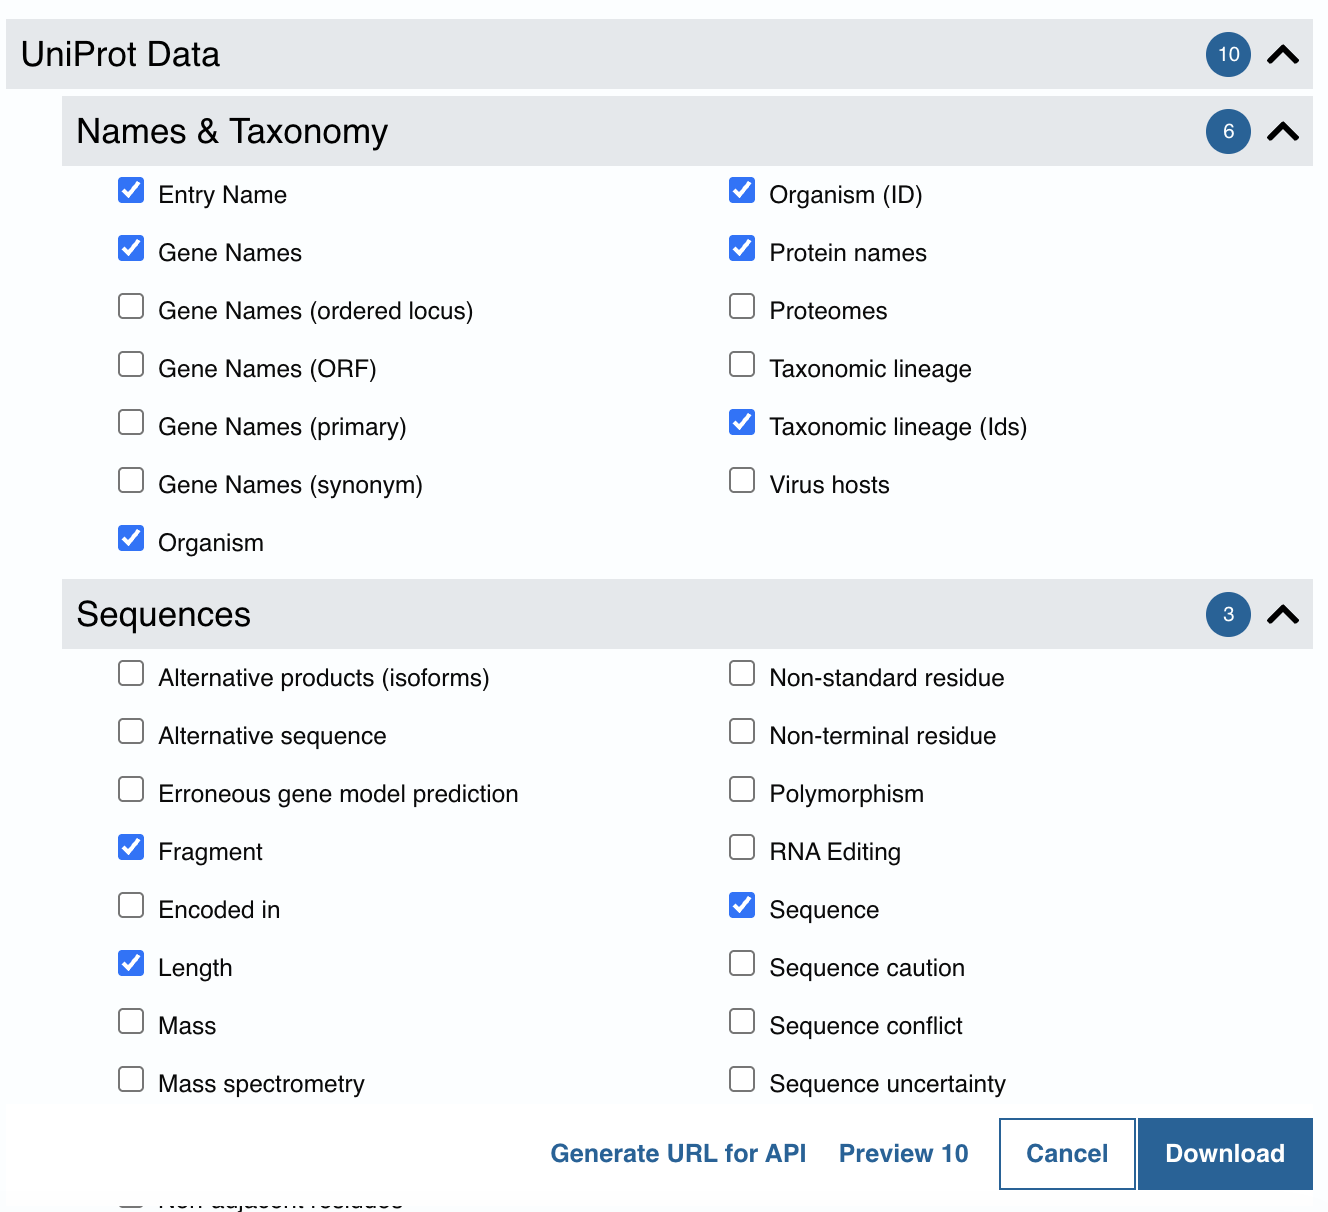

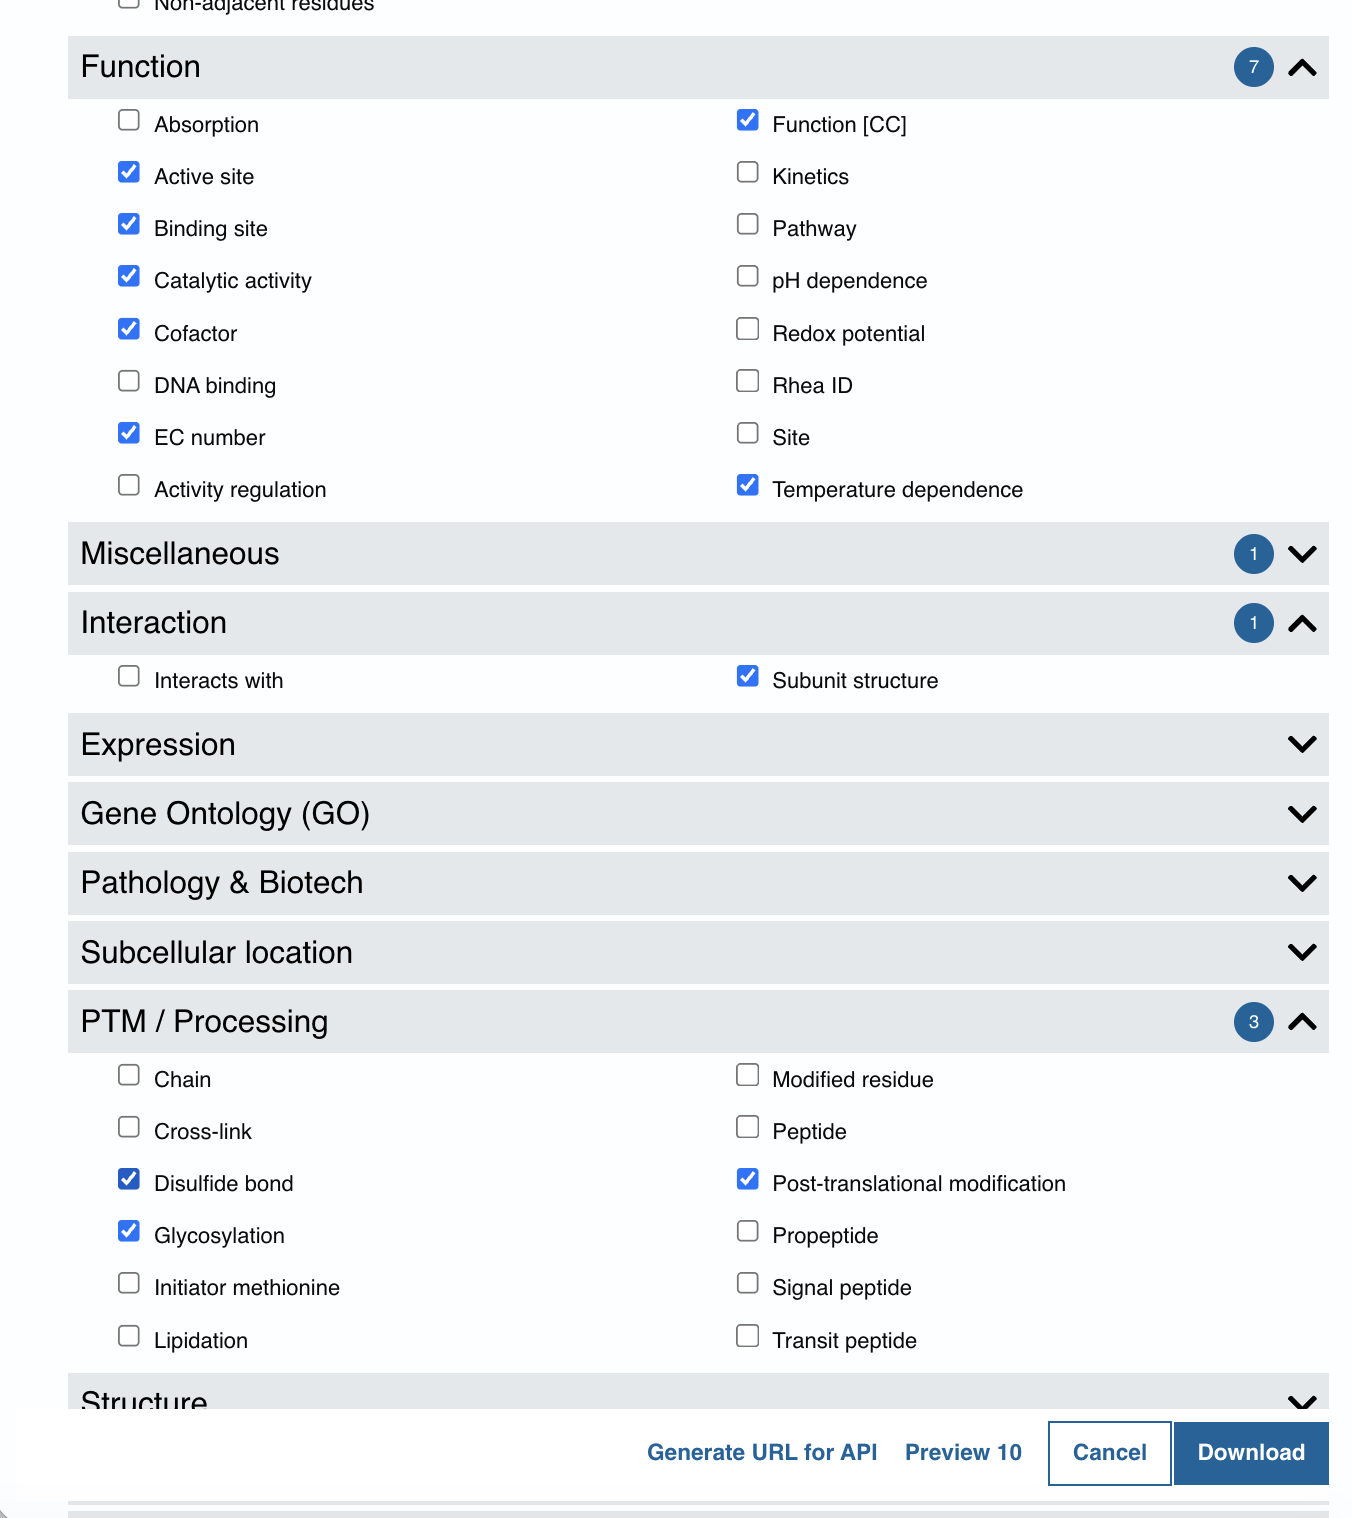

Then click the download.
The file is now our TSV file we are loading here

In [5]:
import pandas as pd

# Replace with your name
df = pd.read_csv('uniprotkb_halogenase_AND_reviewed_true_2026_05_25.tsv', sep='\t')

In [6]:
! mkdir tmp

mkdir: cannot create directory ‘tmp’: File exists


In [9]:
!ls

colab_ml_train.py
embed_drfp.py
examples_output
logs
notebook1_embed_your_sequences_with_esm2.ipynb
output
retraining
slurm.sh
tmp
uniprotkb_halogenase_AND_reviewed_true_2026_05_25.tsv


In [8]:
from enzymetk.embedprotein_esm_step import EmbedESM
from enzymetk.save_step import Save
import pandas as pd

id_col = 'Entry' # rename your sequeence labels to Entry if you have some other label it will make your life easier
seq_col = 'Sequence' # rename you sequence column to this if you don't have it yet.
df = df << (EmbedESM(id_col, seq_col, extraction_method='mean', tmp_dir='tmp/', rep_num=36))
print(df)

Boltz: Needs docko package.Install with: pip install docko. Error: {e}
Chai: Needs docko package. Install with: pip install docko. Error: No module named 'docko'
Vina: Needs docko package. Install with: pip install docko. Error: {e}


/mnt/storage01/home/amora/.conda/envs/enzymetk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EmbedESM3: Needs esm3 package. Install with: pip install esm.


/mnt/storage01/home/amora/.conda/envs/enzymetk/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Read tmp//input.fasta with 146 sequences
Processing 1 of 32 batches (15 sequences)
Processing 2 of 32 batches (13 sequences)
Processing 3 of 32 batches (13 sequences)
Processing 4 of 32 batches (11 sequences)
Processing 5 of 32 batches (9 sequences)
Processing 6 of 32 batches (8 sequences)
Processing 7 of 32 batches (8 sequences)
Processing 8 of 32 batches (8 sequences)
Processing 9 of 32 batches (7 sequences)
Processing 10 of 32 batches (7 sequences)
Processing 11 of 32 batches (7 sequences)
Processing 12 of 32 batches (7 sequences)
Processing 13 of 32 batches (6 sequences)
Processing 14 of 32 batches (5 sequences)
Processing 15 of 32 batches (3 sequences)
Processing 16 of 32 batches (2 sequences)
Processing 17 of 32 batches (2 sequences)
Processing 18 of 32 batches (1 sequences)
Processing 19 of 32 batches (1 sequences)
Processing 20 of 32 batches (1 sequences)
Processing 21 of 32 batches (1 sequences)
Processing 22 of 32 batches (1 sequences)
Processing 23 of 32 batches (1 sequences

100%|█| 14

0 0 0
          Entry  Reviewed   Entry Name  \
0    A0A1R3RGK0  reviewed   OTAA_ASPC5   
1    A0A455R4Z0  reviewed   ASCI_ACREG   
2        A1E280  reviewed  TRP6H_STRAO   
3        A2R6H1  reviewed   OTAA_ASPNC   
4        A4D0H5  reviewed  TRP5H_STRRG   
..          ...       ...          ...   
141      Q2UPB9  reviewed   ACLI_ASPOR   
142      Q2UPC2  reviewed   ACLK_ASPOR   
143      R4LHX8  reviewed    FLA_ACTS9   
144      S4S3E3  reviewed   CTCQ_KITAU   
145      P55699  reviewed   Y4XG_SINFN   

                                         Protein names  \
0    Highly reducing polyketide synthase otaA (EC 2...   
1    Terpene cyclase ascI (EC 5.4.99.-) (Ascofurano...   
2    Tryptophan 6-halogenase ThaL (Trp 6-halogenase...   
3    Highly reducing polyketide synthase otaA (EC 2...   
4         Tryptophan 5-halogenase PyrH (EC 1.14.19.58)   
..                                                 ...   
141  Probable aminotransferase aclI (EC 2.6.1.-) (A...   
142  Gamma-glutamyl cyclo

In [10]:
df.to_pickle('examples_output/user_example_esm2_sequences.pkl') # Needs to be a pickle file otherwise the embeddings die

In [11]:
# Delete the tmp directory that we used. Make sure you don't use it for anything else useful.
#! rm -rf tmp 